 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #


from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam


###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [3]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

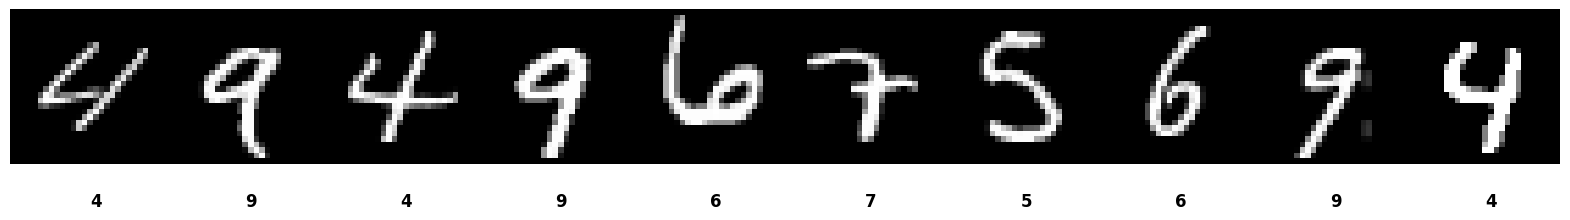

In [5]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [6]:
###################################
# Write your own code here #


(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape para agregar dimensión de canal (28,28) → (28,28,1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Normalización (min-max)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# One-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)


###################################

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [7]:
model = Sequential()
###################################
# Write your own code here #


model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


###################################

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [8]:
loss = None
optimizer = None
metrics = None
learning_rate = 0.0

###################################
# Write your own code here #


loss = 'categorical_crossentropy'
optimizer = Adam(learning_rate=0.001)
metrics = ['accuracy']

model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)


###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [9]:
###################################
# Write your own code here #


history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=1)


###################################

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.8990 - loss: 0.3344 - val_accuracy: 0.9772 - val_loss: 0.0759
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.9689 - loss: 0.1013 - val_accuracy: 0.9851 - val_loss: 0.0526
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.9778 - loss: 0.0738 - val_accuracy: 0.9884 - val_loss: 0.0448
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.9824 - loss: 0.0599 - val_accuracy: 0.9876 - val_loss: 0.0429
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9850 - loss: 0.0496 - val_accuracy: 0.9852 - val_loss: 0.0493
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.9864 - loss: 0.0457 - val_accuracy: 0.9896 - val_loss: 0.0369
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9883 - loss: 0.0379 - val_accuracy: 0.9893 - val_loss: 0.0402
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9890 - loss: 0

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

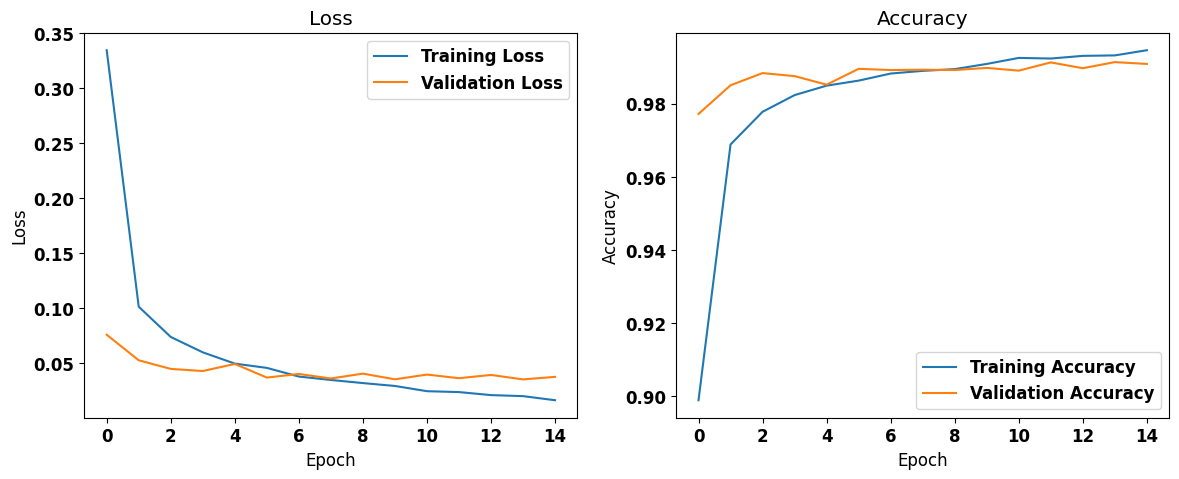

In [10]:
###################################
# Write your own code here #


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

Test Loss: 0.0248
Test Accuracy: 99.25%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


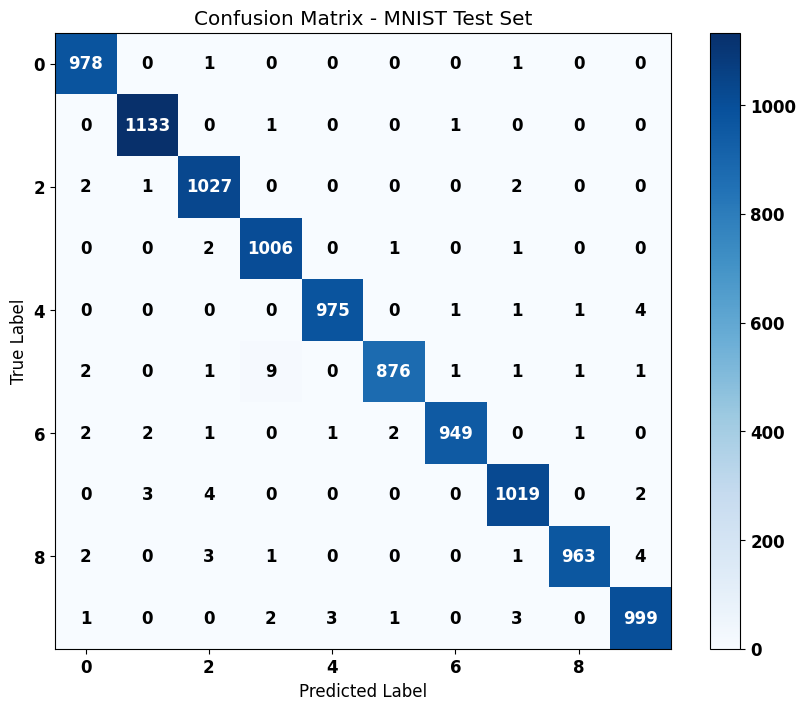


Classification Report:
Class | Precision | Recall | F1-Score | Support
--------------------------------------------------
    0 | 0.9909    | 0.9980  | 0.9944   |   980
    1 | 0.9947    | 0.9982  | 0.9965   |  1135
    2 | 0.9885    | 0.9952  | 0.9918   |  1032
    3 | 0.9872    | 0.9960  | 0.9916   |  1010
    4 | 0.9959    | 0.9929  | 0.9944   |   982
    5 | 0.9955    | 0.9821  | 0.9887   |   892
    6 | 0.9968    | 0.9906  | 0.9937   |   958
    7 | 0.9903    | 0.9912  | 0.9908   |  1028
    8 | 0.9969    | 0.9887  | 0.9928   |   974
    9 | 0.9891    | 0.9901  | 0.9896   |  1009

Overall Accuracy: 99.25%


In [13]:
# 4. Model evaluation on the test dataset

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix (without seaborn)
cm = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_true_classes, y_pred_classes):
    cm[true, pred] += 1

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - MNIST Test Set')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add numbers inside the matrix
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.show()

# Simple Classification Report (manual)
print("\nClassification Report:")
print("Class | Precision | Recall | F1-Score | Support")
print("-" * 50)

for i in range(10):
    true_pos = cm[i, i]
    precision = true_pos / np.sum(cm[:, i]) if np.sum(cm[:, i]) > 0 else 0
    recall = true_pos / np.sum(cm[i, :]) if np.sum(cm[i, :]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    support = np.sum(cm[i, :])

    print(f"{i:5d} | {precision:.4f}    | {recall:.4f}  | {f1:.4f}   | {support:5d}")

print(f"\nOverall Accuracy: {test_acc * 100:.2f}%")

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

In [16]:
# 5. Hyperparameter tuning and regularization

print("Experiment 1: Base Model")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Experiment 2: More layers
print("\nExperiment 2: Deeper Model (Extra Conv Layer)")
model2 = Sequential()

model2.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Conv2D(128, kernel_size=(3,3), activation='relu'))   # extra layer
model2.add(MaxPooling2D(pool_size=(2,2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(10, activation='softmax'))

model2.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
                      epochs=12,
                      batch_size=128,
                      validation_split=0.2,
                      verbose=1)

test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Experiment 2 - Test Accuracy: {test_acc2 * 100:.2f}%")

# Experiment 3: With L2 Regularization
print("\nExperiment 3: L2 Regularization")
from keras.regularizers import l2

model3 = Sequential()
model3.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2,2)))

model3.add(Flatten())
model3.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.4))
model3.add(Dense(10, activation='softmax'))

model3.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

history3 = model3.fit(X_train, y_train,
                      epochs=12,
                      batch_size=128,
                      validation_split=0.2,
                      verbose=1)

test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Experiment 3 (L2) - Test Accuracy: {test_acc3 * 100:.2f}%")

# Final Comparison
print("\nFinal Results")
print(f"Base Model          : {test_acc * 100:.2f}%")
print(f"Deeper Model        : {test_acc2 * 100:.2f}%")
print(f"Model with L2       : {test_acc3 * 100:.2f}%")

Experiment 1: Base Model
Test Accuracy: 99.25%

Experiment 2: Deeper Model (Extra Conv Layer)
Epoch 1/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.8482 - loss: 0.4855 - val_accuracy: 0.9674 - val_loss: 0.1095
Epoch 2/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - accuracy: 0.9581 - loss: 0.1434 - val_accuracy: 0.9767 - val_loss: 0.0788
Epoch 3/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 114ms/step - accuracy: 0.9711 - loss: 0.1018 - val_accuracy: 0.9818 - val_loss: 0.0616
Epoch 4/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 116ms/step - accuracy: 0.9768 - loss: 0.0788 - val_accuracy: 0.9793 - val_loss: 0.0678
Epoch 5/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.9811 - loss: 0.0639 - val_accuracy: 0.9821 - val_loss: 0.0611
Epoch 6/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 86s 128ms/step - accuracy: 0.9844 - loss: 0.0543 - val_accuracy: 0.9854 - val_loss: 0.0492
Epoch 7/12
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.9859 - loss: 0.0479 - val_accuracy: 0.9864 - val_lo